# Unsupervised Learning — Clustering & Association Rule Mining
### K-Means, Hierarchical Clustering, and Apriori — Finance Domain



## 0. Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded successfully.")

Libraries loaded successfully.



## 1. Dataset — Bank Customer Segmentation




In [ ]:
n_per = 90
segments = [
    ("High Income, High Spend", 95, 12, 82, 10),
    ("High Income, Low Spend",  92, 10, 22, 10),
    ("Low Income, High Spend",  28, 8,  78, 10),
    ("Low Income, Low Spend",   25, 8,  20, 8),
    ("Mid Income, Mid Spend",   55, 10, 50, 12),
]
rows = []
for name, inc_mu, inc_sd, spend_mu, spend_sd in segments:
    income = np.random.normal(inc_mu, inc_sd, n_per)
    spend = np.random.normal(spend_mu, spend_sd, n_per)
    for i, s in zip(income, spend):
        rows.append([i, s])

df = pd.DataFrame(rows, columns=["AnnualIncome_k", "CreditSpendScore"])
df["AnnualIncome_k"] = df["AnnualIncome_k"].clip(10, 150)
df["CreditSpendScore"] = df["CreditSpendScore"].clip(1, 100)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (450, 2)


,AnnualIncome_k,CreditSpendScore
0,100.960570,82.970775
1,93.340828,91.686450
2,102.772262,74.979469
3,113.276358,78.723379
4,92.190160,78.078918


In [ ]:
X = df.values
Xs = StandardScaler().fit_transform(X)  # scaling matters — both algorithms are distance-based

---
## 2. K-Means Clustering



### 2.1 Elbow Method — Choosing k

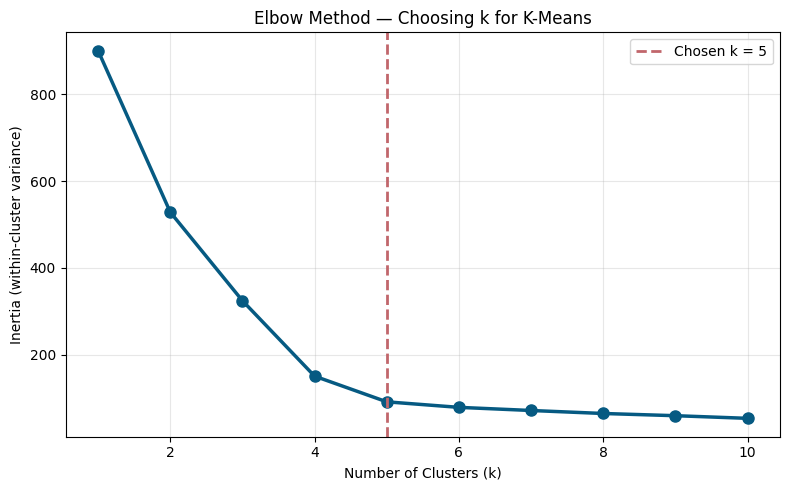

In [ ]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xs)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker="o", color="#065A82", linewidth=2.5, markersize=8)
plt.axvline(5, color="#C1666B", linestyle="--", linewidth=2, label="Chosen k = 5")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (within-cluster variance)")
plt.title("Elbow Method — Choosing k for K-Means")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Fit K-Means (k=5)

In [ ]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
km_labels = km.fit_predict(Xs)
km_sil = silhouette_score(Xs, km_labels)
centers_orig = StandardScaler().fit(X).inverse_transform(km.cluster_centers_)

print(f"K-Means Silhouette Score: {km_sil:.4f}")
df["KMeans_Cluster"] = km_labels

K-Means Silhouette Score: 0.5863


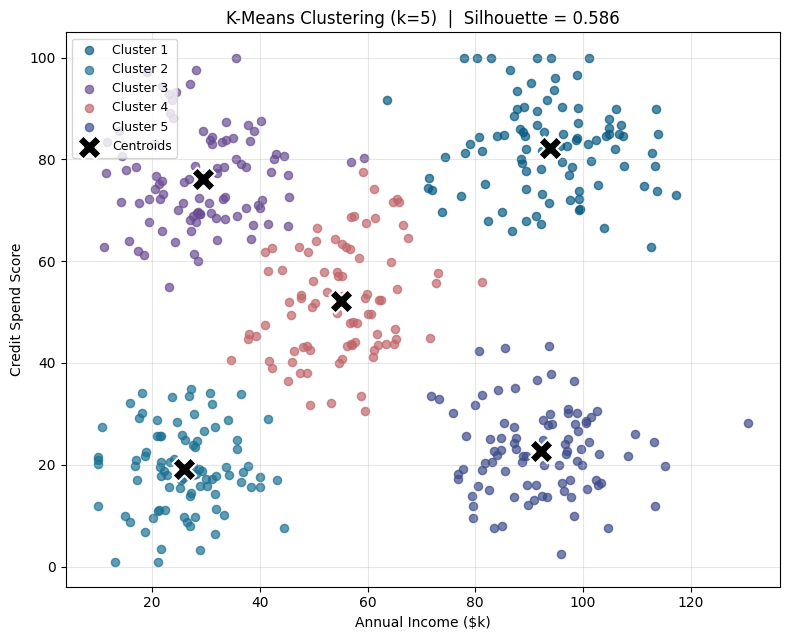

In [ ]:
palette = ["#065A82", "#1C7293", "#6A4C93", "#C1666B", "#3E4C8A"]
plt.figure(figsize=(8, 6.5))
for i in range(5):
    mask = km_labels == i
    plt.scatter(df["AnnualIncome_k"][mask], df["CreditSpendScore"][mask],
                s=35, color=palette[i], alpha=0.7, label=f"Cluster {i+1}")
plt.scatter(centers_orig[:, 0], centers_orig[:, 1], marker="X", s=300, c="black",
            edgecolors="white", linewidths=1.5, label="Centroids", zorder=5)
plt.xlabel("Annual Income ($k)")
plt.ylabel("Credit Spend Score")
plt.title(f"K-Means Clustering (k=5)  |  Silhouette = {km_sil:.3f}")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Hierarchical Clustering




### 3.2 Dendrogram

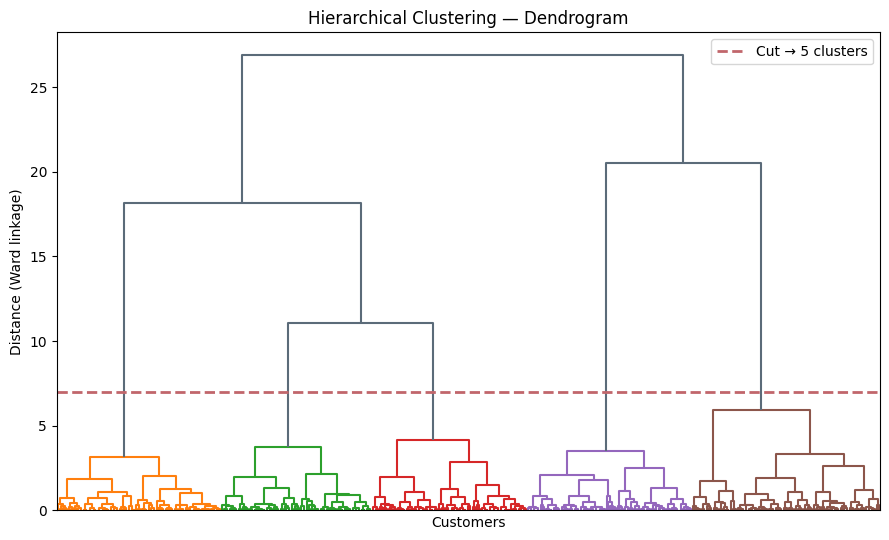

In [ ]:
linked = linkage(Xs, method="ward")

plt.figure(figsize=(9, 5.5))
dendrogram(linked, color_threshold=7, above_threshold_color="#5B6B79", no_labels=True)
plt.axhline(7, color="#C1666B", linestyle="--", linewidth=2, label="Cut \u2192 5 clusters")
plt.xlabel("Customers")
plt.ylabel("Distance (Ward linkage)")
plt.title("Hierarchical Clustering — Dendrogram")
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Fit Hierarchical Clustering & Compare to K-Means

In [ ]:
hc = AgglomerativeClustering(n_clusters=5, linkage="ward")
hc_labels = hc.fit_predict(Xs)
hc_sil = silhouette_score(Xs, hc_labels)
df["Hierarchical_Cluster"] = hc_labels

print(f"K-Means Silhouette:      {km_sil:.4f}")
print(f"Hierarchical Silhouette: {hc_sil:.4f}")

K-Means Silhouette:      0.5863
Hierarchical Silhouette: 0.5592


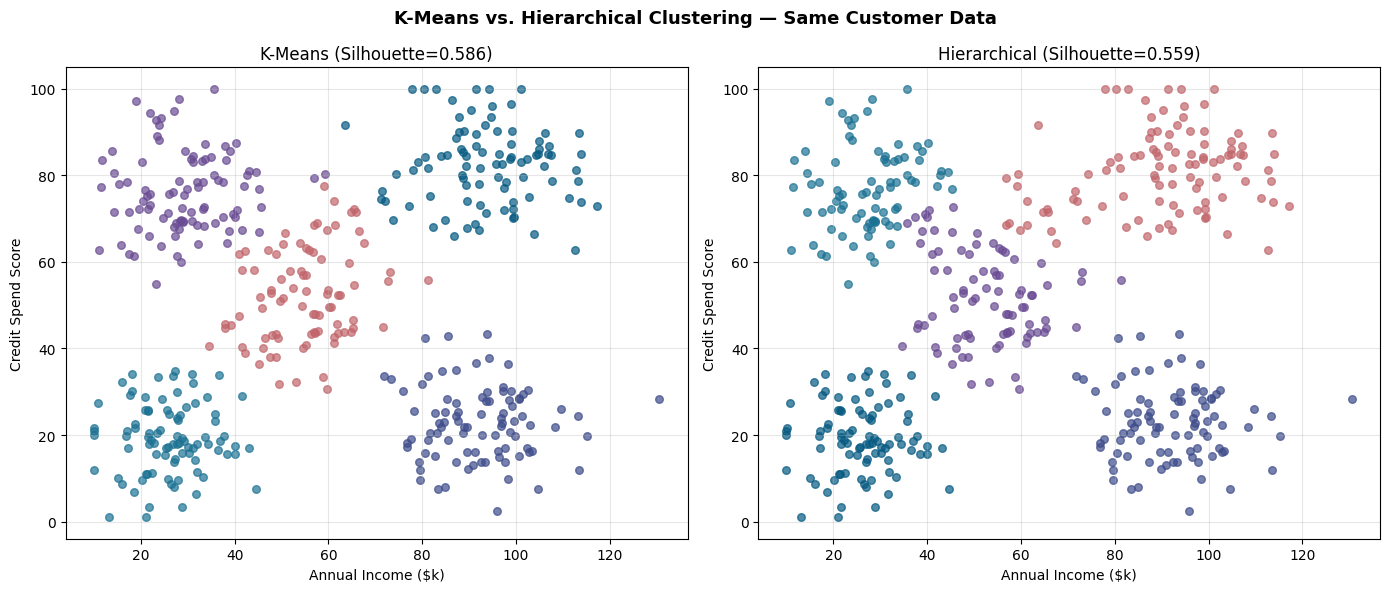

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i in range(5):
    mask = km_labels == i
    axes[0].scatter(df["AnnualIncome_k"][mask], df["CreditSpendScore"][mask], s=30, color=palette[i], alpha=0.7)
axes[0].set_title(f"K-Means (Silhouette={km_sil:.3f})")
axes[0].set_xlabel("Annual Income ($k)"); axes[0].set_ylabel("Credit Spend Score")
axes[0].grid(alpha=0.3)

hc_order = pd.Series(hc_labels).groupby(hc_labels).apply(lambda idx: df["AnnualIncome_k"].values[idx.index].mean())
for i, orig_label in enumerate(hc_order.sort_values().index):
    mask = hc_labels == orig_label
    axes[1].scatter(df["AnnualIncome_k"][mask], df["CreditSpendScore"][mask], s=30, color=palette[i], alpha=0.7)
axes[1].set_title(f"Hierarchical (Silhouette={hc_sil:.3f})")
axes[1].set_xlabel("Annual Income ($k)"); axes[1].set_ylabel("Credit Spend Score")
axes[1].grid(alpha=0.3)

plt.suptitle("K-Means vs. Hierarchical Clustering — Same Customer Data", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Association Rule Mining — Banking Product Bundles




### 4.1 Dataset — Simulated Customer Product Holdings

In [ ]:
n_customers = 800
transactions = []
for _ in range(n_customers):
    basket = set()
    if np.random.rand() < 0.85:
        basket.add("Savings Account")
    if "Savings Account" in basket and np.random.rand() < 0.75:
        basket.add("Debit Card")
    if "Savings Account" in basket and np.random.rand() < 0.55:
        basket.add("Credit Card")
    if np.random.rand() < 0.3:
        basket.add("Mortgage")
        if np.random.rand() < 0.7:
            basket.add("Insurance")
    if np.random.rand() < 0.35:
        basket.add("Mutual Fund")
        if np.random.rand() < 0.65:
            basket.add("Fixed Deposit")
    if "Credit Card" in basket and np.random.rand() < 0.25:
        basket.add("Personal Loan")
    elif np.random.rand() < 0.1:
        basket.add("Personal Loan")
    if len(basket) == 0:
        basket.add("Savings Account")
    transactions.append(list(basket))

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)
print("Transactions:", basket_df.shape[0], " Products:", basket_df.shape[1])
basket_df.head()

Transactions: 800  Products: 8


,Credit Card,Debit Card,Fixed Deposit,Insurance,Mortgage,Mutual Fund,Personal Loan,Savings Account
0,False,False,True,False,False,True,False,True
1,False,False,True,False,False,True,False,False
2,False,True,False,False,False,False,False,True
3,True,False,False,False,False,False,True,True
4,True,True,True,False,False,True,True,True


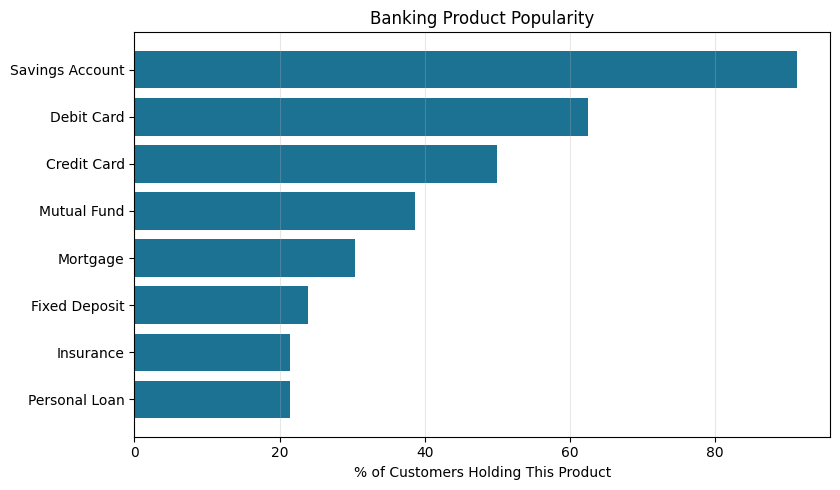

In [ ]:
plt.figure(figsize=(8.5, 5))
pop = basket_df.mean().sort_values(ascending=True) * 100
plt.barh(pop.index, pop.values, color="#1C7293")
plt.xlabel("% of Customers Holding This Product")
plt.title("Banking Product Popularity")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### 4.2 Apriori Algorithm — Frequent Itemsets & Rules

In [ ]:
freq_items = apriori(basket_df, min_support=0.08, use_colnames=True)
rules = association_rules(freq_items, metric="lift", min_threshold=1.1)

# Keep simple 1-to-1 rules for a clean, presentable set
simple_rules = rules[(rules["antecedents"].apply(len) == 1) & (rules["consequents"].apply(len) == 1)].copy()
simple_rules["antecedent"] = simple_rules["antecedents"].apply(lambda x: list(x)[0])
simple_rules["consequent"] = simple_rules["consequents"].apply(lambda x: list(x)[0])
simple_rules = simple_rules.sort_values("lift", ascending=False).drop_duplicates(subset=["lift"]).head(8)

simple_rules[["antecedent", "consequent", "support", "confidence", "lift"]]

,antecedent,consequent,support,confidence,lift
7,Mortgage,Insurance,0.21500,0.707819,3.292181
6,Insurance,Mortgage,0.21500,1.000000,3.292181
5,Fixed Deposit,Mutual Fund,0.23875,1.000000,2.588997
4,Mutual Fund,Fixed Deposit,0.23875,0.618123,2.588997
2,Credit Card,Personal Loan,0.15750,0.315000,1.473684
0,Debit Card,Credit Card,0.35375,0.566000,1.132000


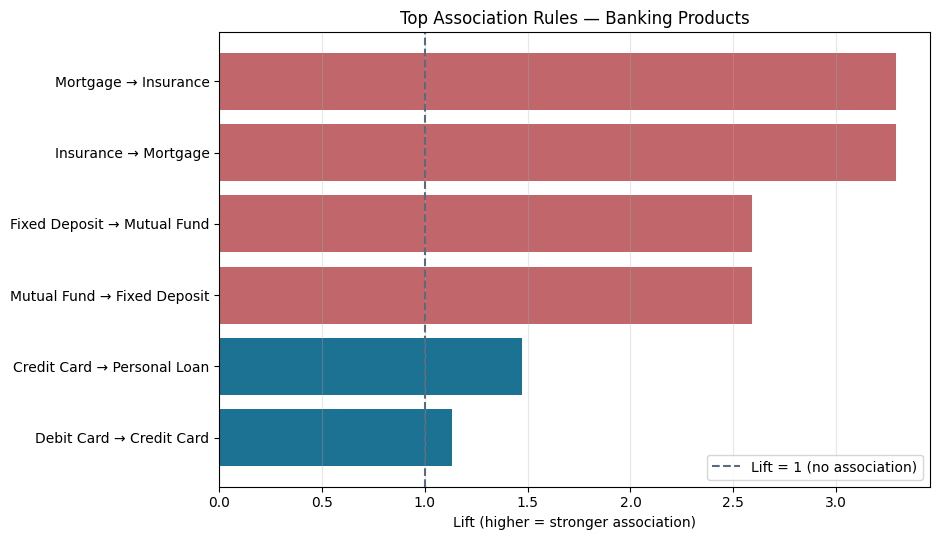

In [ ]:
plt.figure(figsize=(9.5, 5.5))
labels = [f"{r.antecedent} \u2192 {r.consequent}" for r in simple_rules.itertuples()]
colors = ["#C1666B" if l > 2 else "#1C7293" for l in simple_rules["lift"]]
plt.barh(labels[::-1], simple_rules["lift"].values[::-1], color=colors[::-1])
plt.axvline(1, color="#5B6B79", linestyle="--", linewidth=1.5, label="Lift = 1 (no association)")
plt.xlabel("Lift (higher = stronger association)")
plt.title("Top Association Rules — Banking Products")
plt.legend(loc="lower right")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

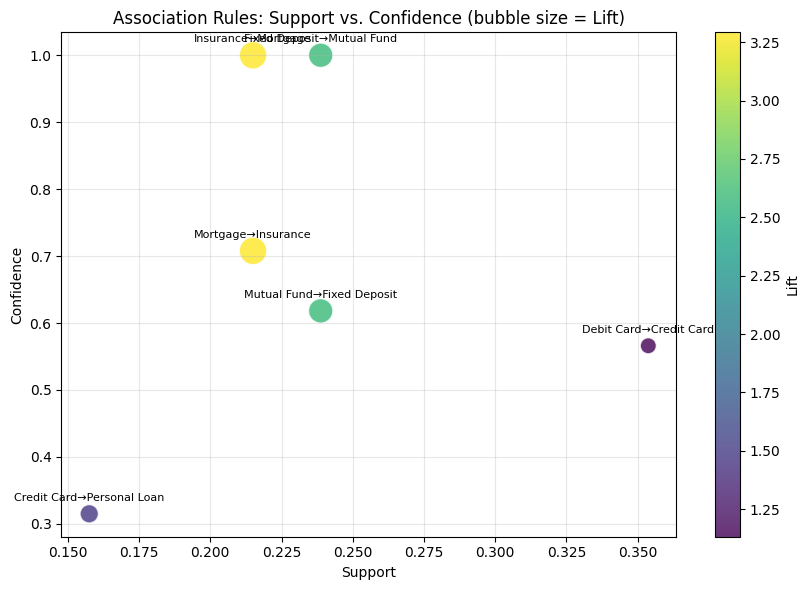

In [ ]:
plt.figure(figsize=(8.5, 6))
sc = plt.scatter(simple_rules["support"], simple_rules["confidence"],
                  s=simple_rules["lift"]*120, c=simple_rules["lift"], cmap="viridis",
                  alpha=0.8, edgecolors="white", linewidths=1)
for r in simple_rules.itertuples():
    plt.annotate(f"{r.antecedent}\u2192{r.consequent}", (r.support, r.confidence),
                 fontsize=8, ha="center", va="bottom", xytext=(0, 8), textcoords="offset points")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs. Confidence (bubble size = Lift)")
plt.colorbar(sc, label="Lift")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()